1. Importando pacotes 

In [38]:
import re 
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
sns.set_style('whitegrid')

2. Carregando e compreendendo os dados

In [21]:
nome_do_arquivo_csv = 'dataset.csv'
df = pd.read_csv(nome_do_arquivo_csv)

In [22]:
df.shape

(500, 3)

In [23]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [24]:
df.sample(10) # amostra aleatória

,review_id,texto_review,sentimento
40,41,A cor do livro é um pouco diferente do que eu ...,positivo
342,343,Amei o mouse! A qualidade é fantástica e a ent...,positivo
488,489,O fone de ouvido é de baixa qualidade. O supor...,negativo
24,25,Ótimo custo-benefício. O mouse é fantástica e ...,positivo
100,101,É um teclado ok pelo preço que paguei.,negativo
474,475,Amei o notebook! A qualidade é excelente e a e...,negativo
102,103,Péssima experiência. O monitor quebrou no prim...,negativo
297,298,É um teclado ok pelo preço que paguei.,negativo
95,96,O notebook é de baixa qualidade. O suporte ao ...,negativo
277,278,A embalagem do fone de ouvido chegou um pouco ...,negativo


3. Análise Exploratória de Dados (EDA)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     500 non-null    int64
 1   texto_review  488 non-null    str  
 2   sentimento    500 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.8 KB


In [26]:
# Verificando valores ausentes
print(f'Verificando valores ausentes:\n{df.isnull().sum()}')

Verificando valores ausentes:
review_id        0
texto_review    12
sentimento       0
dtype: int64


Distribuição dos Sentimentos:



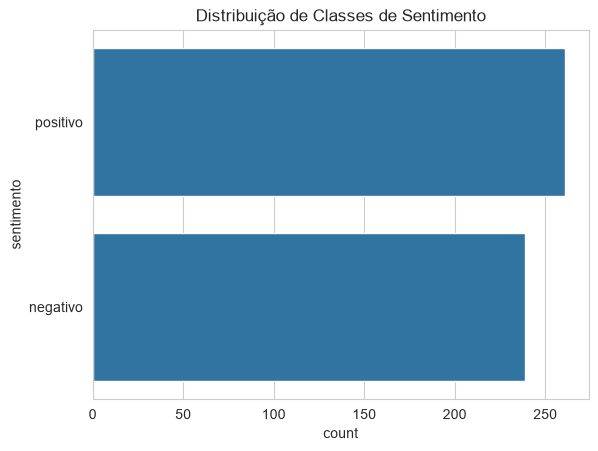

In [27]:
print('Distribuição dos Sentimentos:\n')
sns.countplot(y='sentimento', data=df)
plt.title('Distribuição de Classes de Sentimento')
plt.show()

5. Limpeza de Dados

In [28]:
print(f'\nTamanho original do DataFrame: {len(df)}')
df.dropna(subset=['texto_review'], inplace=True)
print(f'\nTamanho do DF após remover dados nulos: {len(df)}')


Tamanho original do DataFrame: 500

Tamanho do DF após remover dados nulos: 488


In [29]:
df.shape

(488, 3)

In [30]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [31]:
def limpa_texto(texto):
    if not isinstance(texto, str):
        return ""

    texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')
    texto_limpo = texto_sem_acentos.lower()
    texto_limpo = re.sub(r'[^a-z\s]', '', texto_limpo)
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()

    return texto_limpo


In [32]:
df['texto_limpo'] = df['texto_review'].apply(limpa_texto)

In [33]:
df.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


6. Engenharia de Atributos

In [34]:
df['sentimento_label'] = df['sentimento'].map({'positivo': 1, 'negativo': 0})

In [35]:
print('DataFrame após a limpeza e mapeamento:\n')
df[['texto_limpo', 'sentimento_label']].head()

DataFrame após a limpeza e mapeamento:



,texto_limpo,sentimento_label
0,estou muito feliz com a compra o cadeira gamer...,1
2,nao recomendo a entrega foi lenta e o celular ...,0
3,o monitor e decepcionante o suporte ao cliente...,1
4,e um livro ok pelo prceo que paguei,0
5,nao rceomendo a entrega atrasou muito e o moni...,1


7. Divisão em Dados de Treino de Teste

In [36]:
X = df['texto_limpo']
y = df['sentimento_label']

In [45]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

8. Pipeline de Modelagem Preditiva

In [47]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=['de','a','o', 'que', 'e', 'do', 'da', 'em', 'um'])),
    ('scaler', StandardScaler(with_mean=False)),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

In [48]:
# Otimização de hiperparâmetros
parametros_grid = {
    'tfidf__max_features': [500,1000,2000], 
    'tfidf__ngram_range': [(1,1), (1,2)],
    'logreg__C': [0.1, 1, 10], 
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [5000, 6000]
}

In [49]:
grid_search = GridSearchCV(
    pipeline, 
    parametros_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

In [50]:
# Treinamento do modelo

print(f'Iniciando o treinamento do modelo com otimização de hiperparâmetros...\n')
grid_search.fit(X_treino, y_treino)

Iniciando o treinamento do modelo com otimização de hiperparâmetros...

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\gabriel.aalves\analise_sentimentos_dsa\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gabriel.aalves\analise_sentimentos_dsa\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.1, 1, ...], 'logreg__max_iter': [5000, 6000], 'logreg__penalty': ['l1', 'l2'], 'tfidf__max_features': [500, 1000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :r

In [51]:
print('Melhores hiperparâmetros encontrados:\n')
print(grid_search.best_params_)

Melhores hiperparâmetros encontrados:

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [52]:
melhor_modelo = grid_search.best_estimator_

9. Avaliação do Modelo e Interpretação das Métricas

In [53]:
y_pred = melhor_modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred, target_names=['Negativo', 'Positivo'])
print(f'Acurácia do Modelo: {acuracia:.2%}\n')
print('Relatório de Classificação:\n')
print(report)

Acurácia do Modelo: 81.15%

Relatório de Classificação:

              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.80        58
    Positivo       0.83      0.81      0.82        64

    accuracy                           0.81       122
   macro avg       0.81      0.81      0.81       122
weighted avg       0.81      0.81      0.81       122



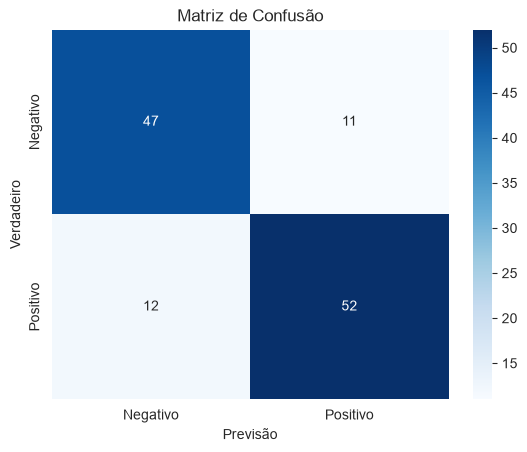

In [54]:
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
)
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

In [56]:
# se tivermos satisfeitos com a performance do modelo, salvamos em disco 
joblib.dump(melhor_modelo, 'modelo_sentimento_v1.joblib')
del melhor_modelo

10. MLOps, Deploy e Uso do Modelo

In [57]:
modelo_deploy = joblib.load('modelo_sentimento_v1.joblib')

In [58]:
novos_reviews = [
    "A bateria do celular não dura nada, péssima compra.",
    "Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.",
    "O serviço de atendimento foi rápido e eficiente.",
    "Não recomendo, veio faltando peças e a cor estava errada."
]

In [59]:
def prever_sentimento(reviews):
    previsoes = modelo_deploy.predict(reviews)
    sentimentos = ['Negativo' if p == 0 else 'Positivo' for p in previsoes]
    for review, sentimento in zip(reviews, sentimentos):
        print(f"\nReview: '{review}'\n Sentimento Previsto: {sentimento}")

In [60]:
prever_sentimento(novos_reviews)


Review: 'A bateria do celular não dura nada, péssima compra.'
 Sentimento Previsto: Negativo

Review: 'Chegou antes do prazo e o produto é de ótima qualidade! Estou muito feliz.'
 Sentimento Previsto: Positivo

Review: 'O serviço de atendimento foi rápido e eficiente.'
 Sentimento Previsto: Negativo

Review: 'Não recomendo, veio faltando peças e a cor estava errada.'
 Sentimento Previsto: Negativo
